In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rc
import mpltern

_dpi = 100


def colormap(num_colors, name = 'rainbow') :
    cmap = mpl.cm.get_cmap(name = name, lut = num_colors)
    return cmap(range(num_colors))

#(10,10), size = 25

rc('text', usetex=True)
rc('font', family='serif', size = 12)

##############"
# Fig12
##############"

"""filename = "Fig12.csv"

data = np.loadtxt(filename, skiprows=1,delimiter=',')
z, V = data.T


#Fit linear : 
P = np.poly1d(np.polyfit(z, V, deg=1))

fig = plt.figure(figsize=(3,3))
ax = fig.subplots()
ax.plot(z, V, marker = 'o', ls = 'none', markersize = 10, color = 'black', label = 'Points calculés')
xlim= ax.get_xlim()
ax.plot(xlim, P(xlim), color = 'red', label = "Régression linéaire")

ax.set_xlabel("z dans $LiNi_{1-z}Co_z O_2$")
ax.set_ylabel("Volume de la maille [$\mathring{A}^3$]")

ax.set_xlim(0,1)

ax.grid()
ax.legend()


#fig.savefig("Fig12.pgf", dpi = _dpi,bbox_inches='tight')"""

'filename = "Fig12.csv"\n\ndata = np.loadtxt(filename, skiprows=1,delimiter=\',\')\nz, V = data.T\n\n\n#Fit linear : \nP = np.poly1d(np.polyfit(z, V, deg=1))\n\nfig = plt.figure(figsize=(3,3))\nax = fig.subplots()\nax.plot(z, V, marker = \'o\', ls = \'none\', markersize = 10, color = \'black\', label = \'Points calculés\')\nxlim= ax.get_xlim()\nax.plot(xlim, P(xlim), color = \'red\', label = "Régression linéaire")\n\nax.set_xlabel("z dans $LiNi_{1-z}Co_z O_2$")\nax.set_ylabel("Volume de la maille [$\\mathring{A}^3$]")\n\nax.set_xlim(0,1)\n\nax.grid()\nax.legend()\n\n\n#fig.savefig("Fig12.pgf", dpi = _dpi,bbox_inches=\'tight\')'

#System Sb-Li

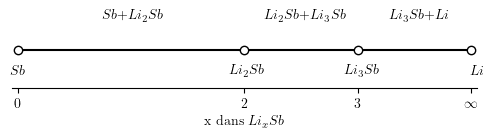

In [17]:
# Choose some nice levels
z = (0,2,3,4)
zticks = ("0", "2", "3", "$\infty$")
names = ('$Sb$', '$Li_2Sb$', '$Li_3Sb$', '$Li$')

# Create figure and plot a stem plot with the date
fig, ax = plt.subplots(figsize=(6, 1))#, layout="constrained")

ax.plot(z, np.zeros_like(z), "-o",
        color="k", markerfacecolor="w")  # Baseline and markers on it.

# annotate lines
for d, r in zip(z, names):
    ax.annotate(r, xy=(d, 0),
               xytext=(d,-20), textcoords="offset points",
               horizontalalignment="center",
               verticalalignment="bottom")

for n in range(len(z)-1) :
    d=(z[n]+z[n+1])/2
    r = names[n] + "+" + names[n+1]
    ax.annotate(r, xy=(d, 0),
               xytext=(d,20), textcoords="offset points",
               horizontalalignment="center",
               verticalalignment="bottom")

# format x-axis with 4-month intervals
#plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

ax.set_xlim(min(z)-0.05,max(z)+0.05)

# remove y-axis and spines
ax.yaxis.set_visible(False)

for axspine in ["left", "top", "right"] :
    ax.spines[axspine].set_visible(False)

ax.set_xlabel("x dans $Li_xSb$")

ax.set_xticks(z)
ax.set_xticklabels(zticks)

#ax.margins(y=0.1)

fig.savefig("Fig04.pgf", dpi = _dpi,bbox_inches='tight')

16
[[1. 0. 0.]
 [0. 1. 0.]] ['$C$' '$A$']


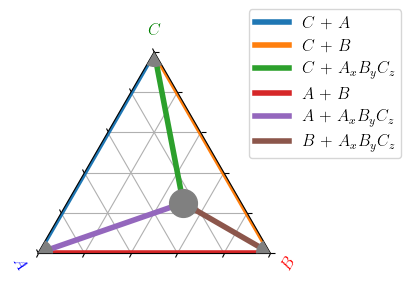

In [83]:
from itertools import product,permutations,pairwise,combinations

nameCP = ('$C$', '$A$', '$B$', '$A_xB_yC_z$')
CP = ([1,0,0], [0,1,0], [0,0,1], [1/3,1/3, 2/3])


fig = plt.figure(figsize = (3,3))
ax = plt.subplot(projection="ternary", ternary_sum=1)

ax.set_tlabel("$C$",color='green')
ax.set_llabel("$A$",color = 'blue')
ax.set_rlabel("$B$", color = 'red')

#ax.plot([1/3, 1/3], [0, 1], transform=ax.get_raxis_transform(), color = 'black')
#ax.scatter(t_comp,l_comp,r_comp, 
#           color='white', s=100, edgecolors = "black", linewidth=2,alpha=1,zorder=3)


#ax.text(t_comp[0]+0.02, l_comp[0]-0.1, r_comp[0]+0.1, '$LiNi_{2/3}Co_{1/3}O_2$', ha='center', va='center')
#ax.text(t_comp[1]+0.05, l_comp[1], r_comp[1]+0.14, '$LiNi_{1/2}Mn_{1/2}O_2$', ha='center', va='center')
#ax.text(t_comp[2], l_comp[2]-0.14, r_comp[2]+0.14, '$LiNi_{1/3}Co_{1/3}Mn_{1/3}O_2$', ha='center', va='center')

for ncp in range(len(CP)) : 
    ax.scatter(*CP[ncp], color = 'grey', s = 400, zorder = 15)

print(len(list(product(CP,CP))))


prodCP = np.array(list(combinations(CP,2)))
prodnameCP = np.array(list(combinations(nameCP,2)))

print(prodCP[0], prodnameCP[0])

for n in range(len(prodCP)) :
    if not np.array_equal(*prodCP[n]) : 
        ax.plot(*prodCP[n].T, label = "{} + {}".format(*prodnameCP[n].T), lw = 4)

ax.grid()
ax.legend(bbox_to_anchor=(0.8, 1),
          bbox_transform=fig.transFigure)

ax.taxis.set_ticklabels([])
ax.raxis.set_ticklabels([])
ax.laxis.set_ticklabels([])

fig.savefig("Fig07b.pgf", dpi = _dpi,bbox_inches='tight')


Hystèrès

/tmp/ipykernel_26770/3611887388.py:4: RuntimeWarning: divide by zero encountered in log
  G = lambda x :  B*x + x*np.log(x) + (1-x)*np.log(1-x) + A * x * (1-x)
/tmp/ipykernel_26770/3611887388.py:4: RuntimeWarning: invalid value encountered in multiply
  G = lambda x :  B*x + x*np.log(x) + (1-x)*np.log(1-x) + A * x * (1-x)
/tmp/ipykernel_26770/3611887388.py:5: RuntimeWarning: divide by zero encountered in log
  V = lambda x : - (B + (np.log(x) - np.log(1-x)) + A *(1-2*x))


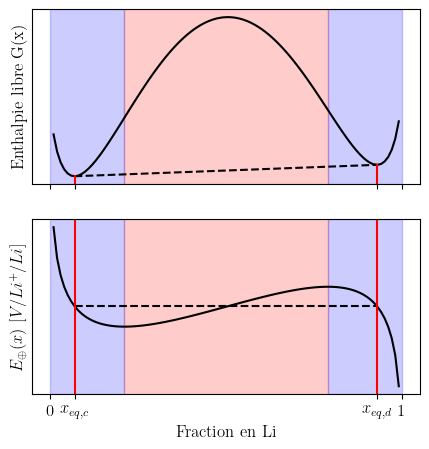

In [152]:
x = np.linspace(0,1, num = 101)
A = 3
B = 0.01
G = lambda x :  B*x + x*np.log(x) + (1-x)*np.log(1-x) + A * x * (1-x)
V = lambda x : - (B + (np.log(x) - np.log(1-x)) + A *(1-2*x))
Vp = lambda x : 2*A - 1/x - 1/(1-x)


xiso_p =  1/2 + 1/2*np.sqrt(1-2/A)
xiso_m =  1/2 - 1/2*np.sqrt(1-2/A)

xeq_m = newton(V, xiso_m-0.1, fprime = Vp)
xeq_p = newton(V, xiso_p+0.1, fprime = Vp)

fig = plt.figure(figsize = (5,5))
ax1, ax2 = fig.subplots(nrows=2, sharex = True)

ax1.plot(x, G(x), color = 'black')
ax2.plot(x, V(x), color = 'black')
ax2.plot([xeq_m, xeq_p], [V(xeq_m), V(xeq_p)], color = 'black', ls = 'dashed', label = 'f.e.m')


ax1.axvspan(xmin = xiso_m, xmax = xiso_p, color = 'red', alpha =0.2)
ax1.axvspan(xmin = 0, xmax = xiso_m, color = 'blue', alpha =0.2)
ax1.axvspan(xmin = xiso_p, xmax = 1, color = 'blue', alpha =0.2)

ax2.axvspan(xmin = xiso_m, xmax = xiso_p, color = 'red', alpha =0.2)
ax2.axvspan(xmin = 0, xmax = xiso_m, color = 'blue', alpha =0.2)
ax2.axvspan(xmin = xiso_p, xmax = 1, color = 'blue', alpha =0.2)

ylim1 = ax1.get_ylim()
ax1.plot([xeq_m, xeq_p], [G(xeq_m), G(xeq_p)], ls = "dashed", color = "black")

ax1.axvline(x=xeq_m, color = 'red', ymax = (G(xeq_m)-ylim1[0])/(ylim1[1]-ylim1[0]))
ax1.axvline(x=xeq_p, color = 'red', ymax = (G(xeq_p)-ylim1[0])/(ylim1[1]-ylim1[0]))

ax2.axvline(x=xeq_m, color = 'red')
ax2.axvline(x=xeq_p, color = 'red')



ax1.set_yticks([])
ax2.set_yticks([])

ax2.set_xticks([0,xeq_p, xeq_m,1])#"$x_{eq,c}$")
ax2.set_xticklabels([0,"$x_{eq,d}$", "$x_{eq,c}$",1])

ax2.set_xlabel("Fraction en Li")
ax1.set_ylabel("Enthalpie libre G(x)")
ax2.set_ylabel("$E_\oplus (x)$ [$V/Li^+ / Li$]")

fig.savefig("Fig14.svg", dpi = _dpi, bbox_inches='tight')

/tmp/ipykernel_26770/3611887388.py:5: RuntimeWarning: divide by zero encountered in log
  V = lambda x : - (B + (np.log(x) - np.log(1-x)) + A *(1-2*x))


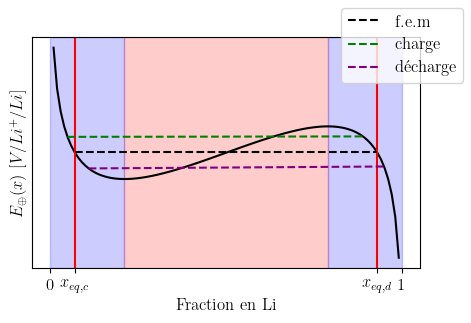

In [156]:
shift = 0.04

fig = plt.figure(figsize = (5,3))
ax = fig.subplots(nrows=1)

ax.plot(x, V(x), color = 'black')

ax.axvspan(xmin = xiso_m, xmax = xiso_p, color = 'red', alpha =0.2)
ax.axvspan(xmin = 0, xmax = xiso_m, color = 'blue', alpha =0.2)
ax.axvspan(xmin = xiso_p, xmax = 1, color = 'blue', alpha =0.2)

ax.axvline(x=xeq_m, color = 'red')
ax.axvline(x=xeq_p, color = 'red')

ax.set_xticks([0,xeq_p, xeq_m,1])#"$x_{eq,c}$")
ax.set_xticklabels([0,"$x_{eq,d}$", "$x_{eq,c}$",1])
ax.set_yticks([])

ax.plot([xeq_m, xeq_p], [V(xeq_m), V(xeq_p)], color = 'black', ls = 'dashed', label = 'f.e.m')
ax.plot([xeq_m-0.02, xeq_p-shift], [V(xeq_m-0.02), V(xeq_p-shift)], color = 'green', ls = 'dashed', label = 'charge')
ax.plot([xeq_m+shift, xeq_p+0.02], [V(xeq_m+shift), V(xeq_p+0.02)], color = 'purple', ls = 'dashed', label = 'décharge')

ax.set_xlabel("Fraction en Li")
ax.set_ylabel("$E_\oplus (x)$ [$V/Li^+ / Li$]")

fig.legend()

fig.savefig("Fig15.svg", dpi = _dpi, bbox_inches='tight')
